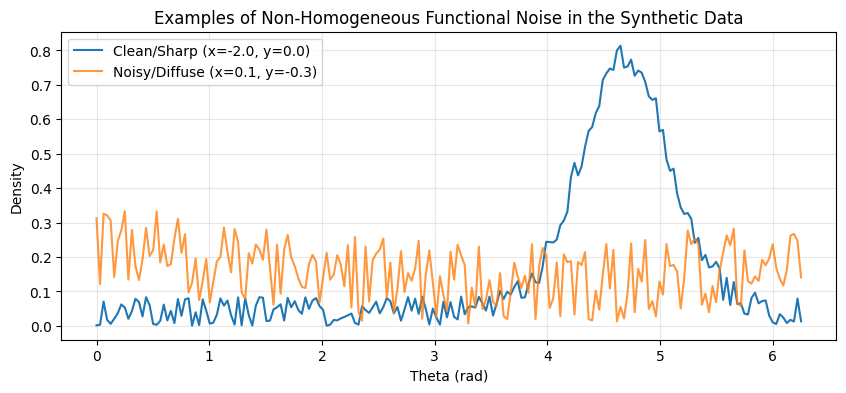

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import vonmises

# ==========================================
# 1. Synthetic Data Generation (Spiral Field)
# ==========================================
np.random.seed(42)
N_samples = 80
X_samples = np.random.uniform(-2, 2, (N_samples, 2))

# True spiral angle: arctan2(y, x) + pi/2
true_angles = (np.arctan2(X_samples[:, 1], X_samples[:, 0]) + np.pi/2) % (2 * np.pi)

# ==========================================
# 2. Non-Homogeneous Noise Parameters
# ==========================================
# Spatial distance from origin ||x||_2
distances = np.linalg.norm(X_samples, axis=1)

# Structural Noise: Kappa varies spatially. 
# Low kappa (high entropy/noise) near the origin, high kappa far away.
kappas = 0.5 + 3.0 * distances 

# Functional Noise Amplitude: Varies linearly along the x-axis.
# Points with positive x-coordinates will have highly corrupted density functions.
noise_amplitudes = 0.1 + 0.5 * (X_samples[:, 0] + 2.0) 

# Discretize the orientation manifold
M_bins = 200
theta = np.linspace(0, 2 * np.pi, M_bins, endpoint=False)
dtheta = theta[1] - theta[0]

# Generate functional data: Corrupted densities at each sample point
densities = np.zeros((N_samples, M_bins))
for i in range(N_samples):
    # 1. Base distribution with spatially varying concentration
    pdf_base = vonmises.pdf(theta - np.pi, kappas[i], loc=true_angles[i] - np.pi)
    
    # 2. Additive functional noise (strictly non-negative to stay in measure space)
    # We use uniformly distributed high-frequency noise scaled by the spatial amplitude
    functional_noise = np.random.uniform(0, 1, M_bins) * noise_amplitudes[i]
    
    # 3. Superposition
    pdf_noisy = pdf_base + functional_noise
    
    # 4. L1 Projection back to the probability simplex P(S^1)
    densities[i, :] = pdf_noisy / np.sum(pdf_noisy * dtheta)

# ==========================================
# Optional: Visualization to verify the noise
# ==========================================
plt.figure(figsize=(10, 4))

# Plot a "clean" high-kappa point (far from origin, negative x)
idx_clean = np.argmin(distances * noise_amplitudes)
plt.plot(theta, densities[idx_clean], label=f'Clean/Sharp (x={X_samples[idx_clean,0]:.1f}, y={X_samples[idx_clean,1]:.1f})')

# Plot a "noisy" low-kappa point (near origin, positive x)
idx_noisy = np.argmax((1/distances) * noise_amplitudes)
plt.plot(theta, densities[idx_noisy], label=f'Noisy/Diffuse (x={X_samples[idx_noisy,0]:.1f}, y={X_samples[idx_noisy,1]:.1f})', alpha=0.8)

plt.title("Examples of Non-Homogeneous Functional Noise in the Synthetic Data")
plt.xlabel("Theta (rad)")
plt.ylabel("Density")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [4]:
# ==========================================
# 1b. Interactive Plotly Visualization (click-to-inspect)
# ==========================================
# Click a sample point to display its functional density (polar + optional hist/KDE).

try:
    import plotly.graph_objects as go
    import ipywidgets as widgets
    from IPython.display import display, clear_output
    from scipy.stats import gaussian_kde
except ImportError as e:
    raise ImportError(
        "Missing optional viz deps. Install with:\n\n"
        "    pip install plotly ipywidgets anywidget\n\n"
        "Then restart the kernel and re-run."
    ) from e

# --- Controls ---
mode = widgets.Dropdown(
    options=[("Polar density", "polar"), ("Line density", "line"), ("Histogram + KDE", "histkde")],
    value="polar",
    description="view",
 )

k_samples = widgets.IntSlider(
    value=2000,
    min=200,
    max=10000,
    step=200,
    description="#samples",
    continuous_update=False,
 )

selected_i = {"i": 0}  # mutable holder for callbacks
selected_label = widgets.HTML(value=f"<b>Selected sample:</b> i={selected_i['i']}")

# --- 1) Sample points scatter (clickable) ---
sample_idx = np.arange(N_samples)
scatter = go.Scattergl(
    x=X_samples[:, 0],
    y=X_samples[:, 1],
    mode="markers",
    marker=dict(
        size=9,
        color=true_angles,
        colorscale="Turbo",
        colorbar=dict(title="true angle"),
        line=dict(width=0.5, color="rgba(0,0,0,0.35)"),
    ),
    customdata=np.stack([sample_idx, true_angles], axis=1),
    hovertemplate=(
        "i=%{customdata[0]:.0f}<br>"
        "x=%{x:.3f}, y=%{y:.3f}<br>"
        "true_angle=%{customdata[1]:.3f} rad<extra></extra>"
    ),
    name="samples",
 )

highlight = go.Scatter(
    x=[float(X_samples[selected_i["i"], 0])],
    y=[float(X_samples[selected_i["i"], 1])],
    mode="markers",
    marker=dict(size=16, color="rgba(0,0,0,0.9)", symbol="circle-open", line=dict(width=3, color="rgba(0,0,0,0.9)")),
    hoverinfo="skip",
    name="selected",
 )

fig_scatter = go.FigureWidget(data=[scatter, highlight])
fig_scatter.update_layout(
    title="Sample points (click a point)",
    xaxis_title="x",
    yaxis_title="y",
    height=420,
    margin=dict(l=40, r=20, t=50, b=40),
    showlegend=False,
 )
fig_scatter.update_yaxes(scaleanchor="x", scaleratio=1)

# --- 2) Density output area (refreshed on click) ---
density_out = widgets.Output()

theta_grid = theta
dtheta_local = float(theta_grid[1] - theta_grid[0])

def _render_density(i: int):
    i = int(i)
    dens = densities[i].astype(float)
    ang = float(true_angles[i])
    title = f"Density at sample i={i} (true angle={ang:.3f} rad)"
    ymax = float(np.max(dens)) * 1.15
    view = mode.value
    
    if view == "polar":
        theta_closed = np.r_[theta_grid, 2 * np.pi]
        dens_closed = np.r_[dens, dens[0]]
        fig = go.Figure()
        fig.add_trace(
            go.Scatterpolar(
                theta=theta_closed,
                r=dens_closed,
                mode="lines",
                line=dict(width=3, color="#1f77b4"),
                hovertemplate="theta=%{theta:.3f}<br>dens=%{r:.4f}<extra></extra>",
            )
        )
        fig.add_trace(
            go.Scatterpolar(
                theta=[ang, ang],
                r=[0, ymax],
                mode="lines",
                line=dict(width=2, dash="dash", color="green"),
                hoverinfo="skip",
            )
        )
        fig.update_layout(
            title=title,
            height=420,
            margin=dict(l=40, r=20, t=50, b=40),
            showlegend=False,
            polar=dict(radialaxis=dict(range=[0, ymax], showgrid=True, gridcolor="rgba(0,0,0,0.1)")),
        )
    elif view == "line":
        fig = go.Figure()
        fig.add_trace(
            go.Scatter(
                x=theta_grid,
                y=dens,
                mode="lines",
                line=dict(width=3, color="#1f77b4"),
                hovertemplate="theta=%{x:.3f}<br>dens=%{y:.4f}<extra></extra>",
            )
        )
        fig.add_vline(x=ang, line_width=2, line_dash="dash", line_color="green")
        fig.update_layout(
            title=title,
            xaxis_title="theta (radians)",
            yaxis_title="density",
            height=420,
            margin=dict(l=40, r=20, t=50, b=40),
            showlegend=False,
        )
    else:
        # Histogram + KDE
        p = dens * dtheta_local
        p = p / np.sum(p)
        n = int(k_samples.value)
        idx = np.random.choice(len(theta_grid), size=n, replace=True, p=p)
        samp = theta_grid[idx]
        samp_aug = np.r_[samp, samp - 2 * np.pi, samp + 2 * np.pi]
        kde = gaussian_kde(samp_aug)
        kde_vals = kde(theta_grid)
        kde_vals = kde_vals / np.sum(kde_vals * dtheta_local)
        fig = go.Figure()
        fig.add_trace(
            go.Histogram(
                x=samp,
                nbinsx=48,
                histnorm="probability density",
                opacity=0.55,
                marker_color="rgba(31,119,180,0.55)",
                hovertemplate="theta=%{x:.3f}<br>dens=%{y:.4f}<extra></extra>",
            )
        )
        fig.add_trace(
            go.Scatter(
                x=theta_grid,
                y=kde_vals,
                mode="lines",
                line=dict(width=3, color="#d62728"),
                hovertemplate="theta=%{x:.3f}<br>kde=%{y:.4f}<extra></extra>",
            )
        )
        fig.add_vline(x=ang, line_width=2, line_dash="dash", line_color="green")
        fig.update_layout(
            title=title + f" — hist + KDE (n={n})",
            xaxis_title="theta (radians)",
            yaxis_title="density",
            height=420,
            margin=dict(l=40, r=20, t=50, b=40),
            barmode="overlay",
            showlegend=False,
        )
    
    with density_out:
        clear_output(wait=True)
        display(fig)

def _update_selection(i: int):
    selected_i["i"] = int(i)
    selected_label.value = f"<b>Selected sample:</b> i={selected_i['i']}"
    # Move highlight marker
    with fig_scatter.batch_update():
        fig_scatter.data[1].x = [float(X_samples[selected_i["i"], 0])]
        fig_scatter.data[1].y = [float(X_samples[selected_i["i"], 1])]
    _render_density(selected_i["i"])

def _on_click(trace, points, selector):
    if points.point_inds:
        _update_selection(points.point_inds[0])

def _on_mode_change(change):
    if change.get("name") == "value":
        _render_density(selected_i["i"])

def _on_k_change(change):
    if change.get("name") == "value" and mode.value == "histkde":
        _render_density(selected_i["i"])

# Wire interactions
fig_scatter.data[0].on_click(_on_click)
mode.observe(_on_mode_change, names="value")
k_samples.observe(_on_k_change, names="value")

# Initial render
_render_density(selected_i["i"])

display(widgets.VBox([
    widgets.HBox([mode, k_samples, selected_label]),
    widgets.HBox([fig_scatter, density_out]),
]))

# Comparing to real distributional data (EE-1-04-4500x)
This section loads the Excel file in `distributional-data/EE-1-04-4500x.xlsx`, converts the per-angle Gabor intensities into a probability density on $[0,\pi)$, then evaluates **leave-one-out** kernel/Fréchet regression performance.

Metrics reported:
- **Axial angle error** (radians): compares predicted axial mean vs observed `AxialMeanDeg`.
- **$W_2$ distance**: 1D Wasserstein distance between predicted and observed densities on $[0,\pi)$.

In [19]:
import re
from pathlib import Path
import numpy as np
import pandas as pd

def find_repo_file(relative_under_repo: str) -> Path:
    """Find a file by walking upwards from the notebook's CWD."""
    cwd = Path.cwd().resolve()
    for base in [cwd, *cwd.parents]:
        candidate = base / relative_under_repo
        if candidate.exists():
            return candidate
    raise FileNotFoundError(f"Could not find {relative_under_repo!r} from cwd={cwd}")

def _parse_coordinate_xy(coord_str: str) -> np.ndarray:
    # expects '(x, y)'
    m = re.match(r"\(?\s*([\-\d\.]+)\s*,\s*([\-\d\.]+)\s*\)?", str(coord_str).strip())
    if not m:
        raise ValueError(f"Could not parse Coordinate={coord_str!r}")
    return np.array([float(m.group(1)), float(m.group(2))], dtype=float)

def load_gabor_intensity_xlsx(path: str | Path, sheet: str = "gabor_intensity"):
    path = str(path)
    df = pd.read_excel(path, sheet_name=sheet)
    ideg_cols = [c for c in df.columns if isinstance(c, str) and c.startswith("Ideg_")]
    if not ideg_cols:
        raise ValueError("No Ideg_* columns found")
    # sort columns by degree
    degs = np.array([int(c.split("_")[1]) for c in ideg_cols], dtype=int)
    order = np.argsort(degs)
    ideg_cols = [ideg_cols[i] for i in order]
    degs = degs[order]
    theta_rad = np.deg2rad(degs.astype(float))  # expected in [0, pi)
    dtheta = float(np.diff(theta_rad).mean())
    X = np.vstack([_parse_coordinate_xy(c) for c in df["Coordinate"].values])
    intens = df[ideg_cols].to_numpy(dtype=float)
    intens = np.maximum(intens, 0.0)
    # normalize to a density on [0, pi) using discrete integral sum(f * dtheta)=1
    dens = intens / (np.sum(intens, axis=1, keepdims=True) * dtheta + 1e-12)
    axial_mean_rad = np.deg2rad(df["AxialMeanDeg"].to_numpy(dtype=float) % 180.0)
    return {
        "df": df,
        "X": X,
        "theta": theta_rad,
        "dtheta": dtheta,
        "densities": dens,
        "axial_mean": axial_mean_rad,
        "ideg_cols": ideg_cols,
    }

def axial_kernel_regression(X: np.ndarray, angles_axial: np.ndarray, x0: np.ndarray, bandwidth: float) -> float:
    """Axial mean regression on [0, pi) using the double-angle trick."""
    diffs = X - x0.reshape(1, 2)
    sq = np.sum(diffs * diffs, axis=1)
    w = np.exp(-sq / (2 * bandwidth**2))
    w = w / (np.sum(w) + 1e-12)
    # double angle mean -> divide by 2
    sin2 = np.sum(w * np.sin(2 * angles_axial))
    cos2 = np.sum(w * np.cos(2 * angles_axial))
    a = 0.5 * np.arctan2(sin2, cos2)
    return a % np.pi

def _quantile_from_density(theta_grid: np.ndarray, dens: np.ndarray, dtheta: float, p: np.ndarray) -> np.ndarray:
    cdf = np.cumsum(dens * dtheta)
    cdf = np.clip(cdf, 0.0, 1.0)
    c_unique, idx_unique = np.unique(cdf, return_index=True)
    if len(c_unique) < 2:
        return np.full_like(p, float(theta_grid[0]))
    return np.interp(p, c_unique, theta_grid[idx_unique])

def wasserstein2_distance_1d(theta_grid: np.ndarray, dens_p: np.ndarray, dens_q: np.ndarray, dtheta: float, M: int = 256) -> float:
    pgrid = np.linspace(0.001, 0.999, M)
    Qp = _quantile_from_density(theta_grid, dens_p, dtheta, pgrid)
    Qq = _quantile_from_density(theta_grid, dens_q, dtheta, pgrid)
    return float(np.sqrt(np.mean((Qp - Qq) ** 2)))

def frechet_barycenter_1d(theta_grid: np.ndarray, densities: np.ndarray, weights: np.ndarray, dtheta: float, M: int = 256) -> np.ndarray:
    """1D Wasserstein barycenter via weighted quantile averaging."""
    weights = np.maximum(weights, 0.0)
    weights = weights / (np.sum(weights) + 1e-12)
    pgrid = np.linspace(0.001, 0.999, M)
    Qs = np.vstack([_quantile_from_density(theta_grid, densities[i], dtheta, pgrid) for i in range(densities.shape[0])])
    Qbar = np.sum(weights[:, None] * Qs, axis=0)
    dp = float(pgrid[1] - pgrid[0])
    dQ = np.gradient(Qbar)
    f_on_Q = dp / (dQ + 1e-12)
    dens = np.interp(theta_grid, Qbar, f_on_Q, left=0.0, right=0.0)
    dens = np.maximum(dens, 0.0)
    dens = dens / (np.sum(dens) * dtheta + 1e-12)
    return dens

def spatial_weights(X: np.ndarray, x0: np.ndarray, bandwidth: float, exclude_index: int | None = None) -> np.ndarray:
    diffs = X - x0.reshape(1, 2)
    sq = np.sum(diffs * diffs, axis=1)
    w = np.exp(-sq / (2 * bandwidth**2))
    if exclude_index is not None:
        w[exclude_index] = 0.0
    return w / (np.sum(w) + 1e-12)

def axial_angle_error(a: float, b: float) -> float:
    """Minimal axial difference on [0, pi)."""
    d = abs(a - b) % np.pi
    return float(min(d, np.pi - d))

xlsx_path = find_repo_file("distributional-data/EE-1-04-4500x.xlsx")
real = load_gabor_intensity_xlsx(xlsx_path)
X_real = real["X"]
theta_real = real["theta"]
dtheta_real = real["dtheta"]
dens_real = real["densities"]
axial_mean_real = real["axial_mean"]

print("Loaded real dataset:", xlsx_path)
print("  X:", X_real.shape, "densities:", dens_real.shape, "theta bins:", theta_real.shape)
print("  theta range:", float(theta_real.min()), "..", float(theta_real.max()), "(radians)")

# --- Leave-one-out evaluation ---
def evaluate_loocv(bandwidth: float) -> dict:
    n = X_real.shape[0]
    w2s = np.zeros(n)
    ang_errs = np.zeros(n)
    for i in range(n):
        w = spatial_weights(X_real, X_real[i], bandwidth=bandwidth, exclude_index=i)
        pred_dens = frechet_barycenter_1d(theta_real, dens_real, w, dtheta_real, M=256)
        w2s[i] = wasserstein2_distance_1d(theta_real, pred_dens, dens_real[i], dtheta_real, M=256)
        pred_angle = axial_kernel_regression(X_real, axial_mean_real, X_real[i], bandwidth=bandwidth)
        ang_errs[i] = axial_angle_error(pred_angle, float(axial_mean_real[i]))
    return {
        "bandwidth": bandwidth,
        "w2_mean": float(np.mean(w2s)),
        "w2_median": float(np.median(w2s)),
        "axial_err_mean": float(np.mean(ang_errs)),
        "axial_err_median": float(np.median(ang_errs)),
    }

# bandwidth_grid = [5, 10, 15, 20, 30, 40]  # adjust to your coordinate scale
bandwidth_grid = [0.5, 1.0, 2.0, 5.0, 10.0, 20.0]  # adjust to your coordinate scale
results = pd.DataFrame([evaluate_loocv(bw) for bw in bandwidth_grid])
results

Loaded real dataset: /Users/rishabhkumar/spiral-chirals/distributional-data/EE-1-04-4500x.xlsx
  X: (180, 2) densities: (180, 36) theta bins: (36,)
  theta range: 0.0 .. 3.0543261909900767 (radians)


,bandwidth,w2_mean,w2_median,axial_err_mean,axial_err_median
0,0.5,1.607035,1.607902,3.028056e-17,0.000000
1,1.0,1.607035,1.607902,3.028056e-17,0.000000
2,2.0,1.590926,1.594247,5.923385e-12,0.000000
3,5.0,1.245443,1.313406,1.380311e-04,0.000000
4,10.0,0.628144,0.476120,1.080783e-03,0.000007
5,20.0,0.472952,0.402563,2.638406e-02,0.019840


In [18]:
print("\nLOOCV Results:")
print(results[["bandwidth", "w2_mean", "w2_median", "axial_err_mean", "axial_err_median"]])


LOOCV Results:
   bandwidth   w2_mean  w2_median  axial_err_mean  axial_err_median
0          5  1.245443   1.313406        0.000138          0.000000
1         10  0.628144   0.476120        0.001081          0.000007
2         15  0.489942   0.441062        0.004845          0.002462
3         20  0.472952   0.402563        0.026384          0.019840
4         30  0.462818   0.404592        0.108921          0.088213
5         40  0.470358   0.425452        0.190100          0.144693


In [22]:
# ==========================================
# Fit diagnostics: RSS + residual plots
# ==========================================
import matplotlib.pyplot as plt

def loocv_predictions_for_bandwidth(bandwidth: float):
    n = X_real.shape[0]
    pred_dens_all = np.zeros_like(dens_real)
    pred_angle_all = np.zeros(n)
    w2_all = np.zeros(n)
    rss_all = np.zeros(n)
    ang_err_all = np.zeros(n)
    for i in range(n):
        w = spatial_weights(X_real, X_real[i], bandwidth=bandwidth, exclude_index=i)
        pred_dens = frechet_barycenter_1d(theta_real, dens_real, w, dtheta_real, M=256)
        pred_dens_all[i] = pred_dens
        resid = pred_dens - dens_real[i]
        rss_all[i] = float(np.sum(resid**2) * dtheta_real)  # integrated squared error
        w2_all[i] = wasserstein2_distance_1d(theta_real, pred_dens, dens_real[i], dtheta_real, M=256)
        pred_angle = axial_kernel_regression(X_real, axial_mean_real, X_real[i], bandwidth=bandwidth)
        pred_angle_all[i] = pred_angle
        ang_err_all[i] = axial_angle_error(pred_angle, float(axial_mean_real[i]))
    return pred_dens_all, pred_angle_all, rss_all, w2_all, ang_err_all

# Pick a bandwidth (default: best by mean W2)
bw_best = float(results.loc[results["w2_mean"].idxmin(), "bandwidth"])
print(f"\nUsing bandwidth={bw_best} (min w2_mean) for RSS diagnostics")

pred_dens_all, pred_angle_all, rss_i, w2_i, ang_err_i = loocv_predictions_for_bandwidth(bw_best)
rss_total = float(np.sum(rss_i))
rss_mean = float(np.mean(rss_i))

# A simple R^2-like score in density space (relative to predicting the global mean density)
dens_mean = np.mean(dens_real, axis=0)
dens_mean = dens_mean / (np.sum(dens_mean) * dtheta_real + 1e-12)
sst_i = np.sum((dens_real - dens_mean[None, :]) ** 2, axis=1) * dtheta_real
sst_total = float(np.sum(sst_i))
r2_density = float(1.0 - rss_total / (sst_total + 1e-12))

summary = {
    "bandwidth": bw_best,
    "RSS_total": rss_total,
    "RSS_mean": rss_mean,
    "R2_density": r2_density,
    "W2_mean": float(np.mean(w2_i)),
    "AxialErr_mean(rad)": float(np.mean(ang_err_i)),
}
pd.Series(summary)


Using bandwidth=20.0 (min w2_mean) for RSS diagnostics


bandwidth             20.000000
RSS_total             89.847046
RSS_mean               0.499150
R2_density            -0.104120
W2_mean                0.472952
AxialErr_mean(rad)     0.026384
dtype: float64

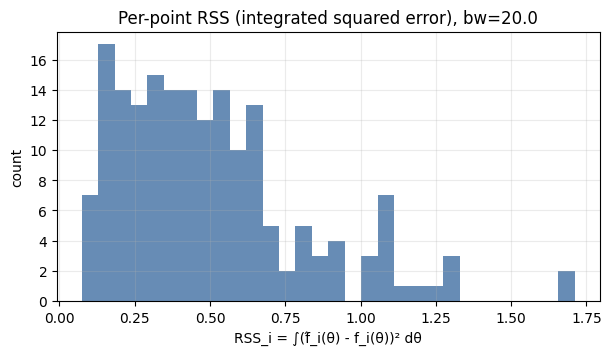

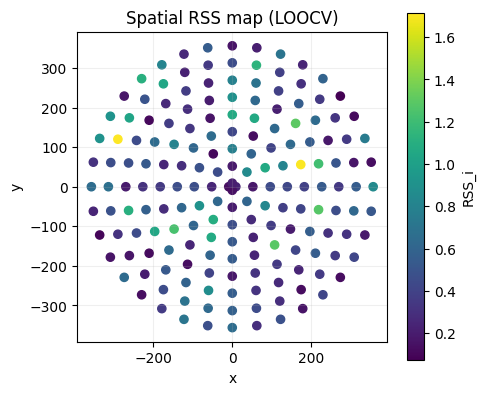

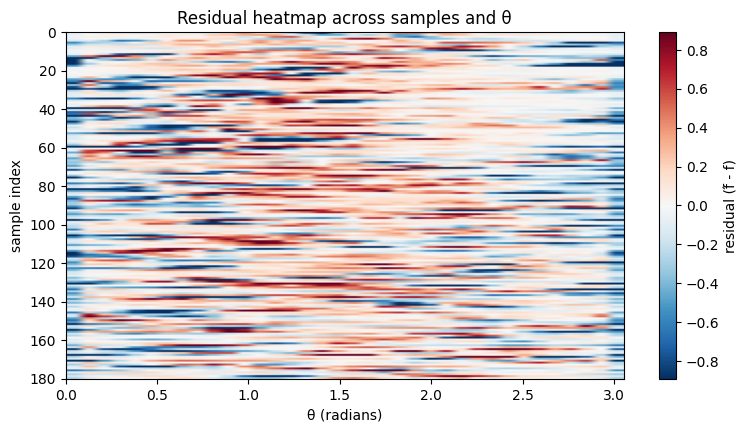

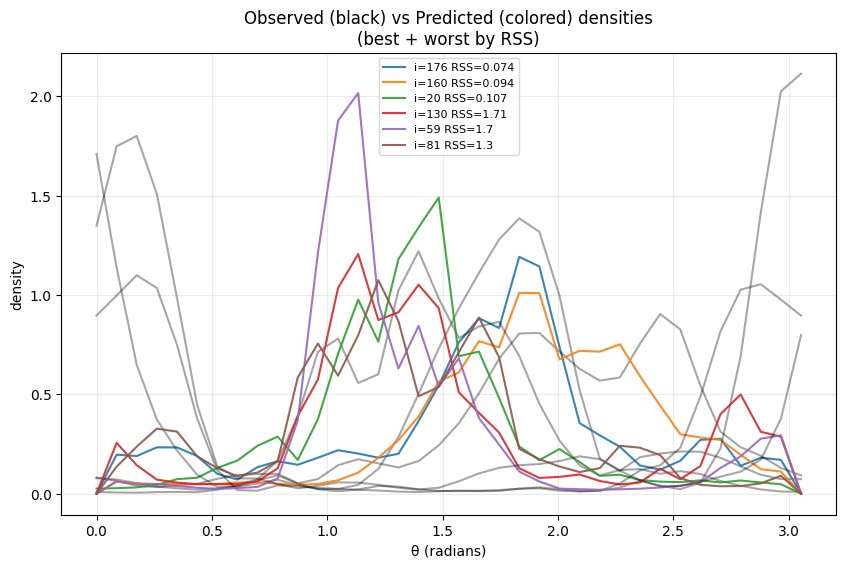

In [23]:
# --- Plots to judge fit ---

# 1) Histogram of per-point RSS
plt.figure(figsize=(7, 3.5))
plt.hist(rss_i, bins=30, color="#4c78a8", alpha=0.85)
plt.title(f"Per-point RSS (integrated squared error), bw={bw_best}")
plt.xlabel("RSS_i = ∫(f̂_i(θ) - f_i(θ))² dθ")
plt.ylabel("count")
plt.grid(True, alpha=0.25)
plt.show()

# 2) Spatial map of RSS (where the model fits poorly)
plt.figure(figsize=(5, 4.5))
sc = plt.scatter(X_real[:, 0], X_real[:, 1], c=rss_i, s=35, cmap="viridis")
plt.gca().set_aspect("equal", adjustable="box")
plt.colorbar(sc, label="RSS_i")
plt.title("Spatial RSS map (LOOCV)")
plt.xlabel("x")
plt.ylabel("y")
plt.grid(True, alpha=0.2)
plt.show()

# 3) Residual heatmap over θ (each row is a sample)
residuals = pred_dens_all - dens_real
plt.figure(figsize=(9, 4.5))
plt.imshow(
    residuals,
    aspect="auto",
    cmap="RdBu_r",
    vmin=-np.percentile(np.abs(residuals), 95),
    vmax=np.percentile(np.abs(residuals), 95),
    extent=[float(theta_real.min()), float(theta_real.max()), len(residuals), 0],
 )
plt.colorbar(label="residual (f̂ - f)")
plt.title("Residual heatmap across samples and θ")
plt.xlabel("θ (radians)")
plt.ylabel("sample index")
plt.show()

# 4) Overlay plots: best vs worst fits
k = 3
worst = np.argsort(rss_i)[-k:][::-1]
best = np.argsort(rss_i)[:k]
sel = np.r_[best, worst]

plt.figure(figsize=(10, 6))
for idx in sel:
    lbl = f"i={idx} RSS={rss_i[idx]:.3g}"
    plt.plot(theta_real, dens_real[idx], color="black", alpha=0.35)
    plt.plot(theta_real, pred_dens_all[idx], alpha=0.9, label=lbl)
plt.title("Observed (black) vs Predicted (colored) densities\n(best + worst by RSS)")
plt.xlabel("θ (radians)")
plt.ylabel("density")
plt.grid(True, alpha=0.25)
plt.legend(fontsize=8)
plt.show()

Streamplot bandwidth = 20.0


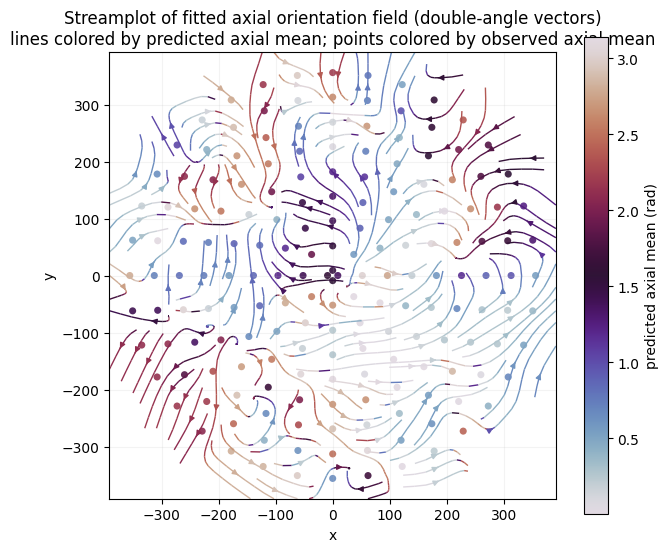

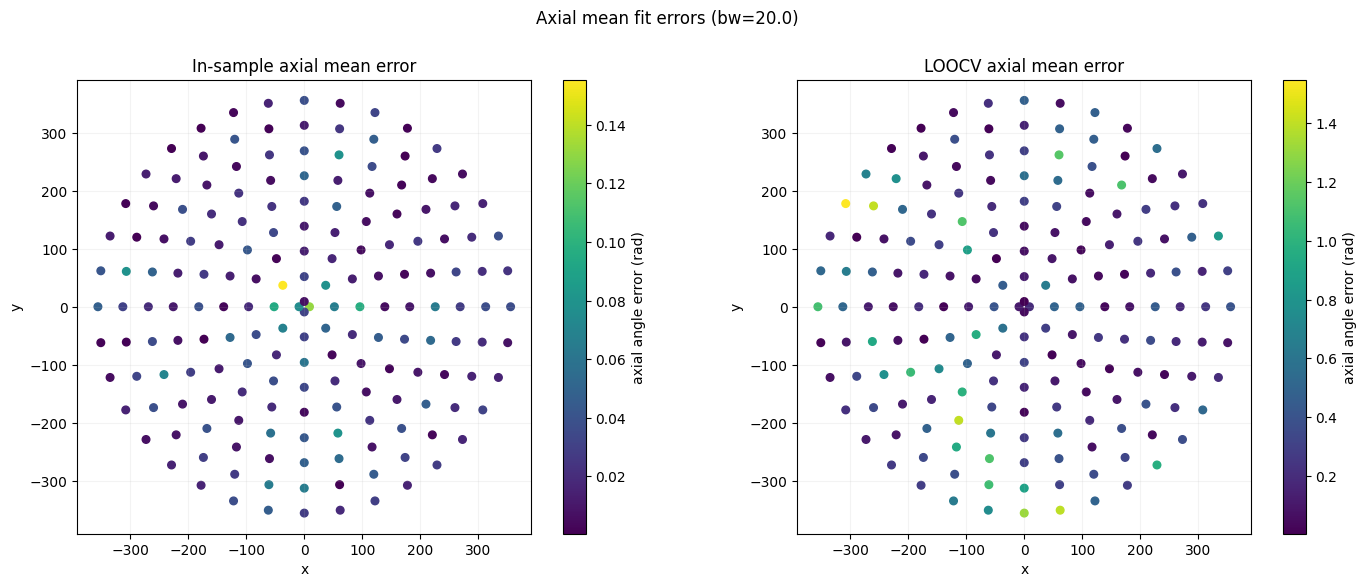

In [26]:
# ==========================================
# Streamplot view of the fitted field (real data)
# ==========================================
# Interprets AxialMeanDeg as an axial orientation in [0, pi).

# Choose bandwidth for visualization (independent of selection strategy)
bw_stream = bw_best if "bw_best" in globals() else float(results.loc[results["w2_mean"].idxmin(), "bandwidth"])
print(f"Streamplot bandwidth = {bw_stream}")

def axial_kernel_regression_all_points(X: np.ndarray, angles_axial: np.ndarray, x0: np.ndarray, bandwidth: float) -> float:
    """Axial mean regression using all points (no leave-one-out)."""
    diffs = X - x0.reshape(1, 2)
    sq = np.sum(diffs * diffs, axis=1)
    w = np.exp(-sq / (2 * bandwidth**2))
    s = np.sum(w)
    if s <= 1e-12:
        return float("nan")
    w = w / s
    sin2 = np.sum(w * np.sin(2 * angles_axial))
    cos2 = np.sum(w * np.cos(2 * angles_axial))
    return float((0.5 * np.arctan2(sin2, cos2)) % np.pi)

def axial_kernel_regression_loocv_at_index(i: int, bandwidth: float) -> float:
    """LOOCV axial mean at sample i (exclude i from weights)."""
    i = int(i)
    w = spatial_weights(X_real, X_real[i], bandwidth=bandwidth, exclude_index=i)
    sin2 = float(np.sum(w * np.sin(2 * axial_mean_real)))
    cos2 = float(np.sum(w * np.cos(2 * axial_mean_real)))
    return float((0.5 * np.arctan2(sin2, cos2)) % np.pi)

# Grid over the domain of observed points
xmin, xmax = float(X_real[:, 0].min()), float(X_real[:, 0].max())
ymin, ymax = float(X_real[:, 1].min()), float(X_real[:, 1].max())
pad_x = 0.05 * (xmax - xmin + 1e-9)
pad_y = 0.05 * (ymax - ymin + 1e-9)
xg = np.linspace(xmin - pad_x, xmax + pad_x, 80)
yg = np.linspace(ymin - pad_y, ymax + pad_y, 80)
Xg, Yg = np.meshgrid(xg, yg)

# Predict axial angle at each grid location
Ang = np.empty_like(Xg, dtype=float)
for r in range(Xg.shape[0]):
    for c in range(Xg.shape[1]):
        Ang[r, c] = axial_kernel_regression_all_points(X_real, axial_mean_real, np.array([Xg[r, c], Yg[r, c]]), bandwidth=bw_stream)

# Use doubled-angle vector representation for axial data (avoids sign ambiguity)
U = np.cos(2 * Ang)
V = np.sin(2 * Ang)

# Mask out regions with no support (near-zero kernel weights everywhere)
def _max_weight_at(x0: np.ndarray, bandwidth: float) -> float:
    diffs = X_real - x0.reshape(1, 2)
    sq = np.sum(diffs * diffs, axis=1)
    w = np.exp(-sq / (2 * bandwidth**2))
    return float(np.max(w))

support = np.empty_like(Xg, dtype=float)
for r in range(Xg.shape[0]):
    for c in range(Xg.shape[1]):
        support[r, c] = _max_weight_at(np.array([Xg[r, c], Yg[r, c]]), bw_stream)
mask = support < 1e-3
U = np.where(mask, np.nan, U)
V = np.where(mask, np.nan, V)
Ang_plot = np.where(mask, np.nan, Ang)

# Plot: streamlines colored by predicted axial mean + points colored by observed axial mean
plt.figure(figsize=(7.2, 6.2))
strm = plt.streamplot(xg, yg, U, V, color=Ang_plot, cmap="twilight", density=1.3, linewidth=1.0, arrowsize=0.8)
plt.colorbar(strm.lines, label="predicted axial mean (rad)")
sc = plt.scatter(X_real[:, 0], X_real[:, 1], c=axial_mean_real, s=26, cmap="twilight", edgecolor="none", alpha=0.9)
plt.gca().set_aspect("equal", adjustable="box")
plt.title("Streamplot of fitted axial orientation field (double-angle vectors)\nlines colored by predicted axial mean; points colored by observed axial mean")
plt.xlabel("x")
plt.ylabel("y")
plt.grid(True, alpha=0.15)
plt.show()

# Error maps at sample points: in-sample vs LOOCV (LOOCV is the honest one)
pred_in = np.array([axial_kernel_regression_all_points(X_real, axial_mean_real, X_real[i], bw_stream) for i in range(X_real.shape[0])])
err_in = np.array([axial_angle_error(float(pred_in[i]), float(axial_mean_real[i])) for i in range(X_real.shape[0])])
pred_loo = np.array([axial_kernel_regression_loocv_at_index(i, bw_stream) for i in range(X_real.shape[0])])
err_loo = np.array([axial_angle_error(float(pred_loo[i]), float(axial_mean_real[i])) for i in range(X_real.shape[0])])

plt.figure(figsize=(14.5, 5.6))
plt.subplot(1, 2, 1)
sc1 = plt.scatter(X_real[:, 0], X_real[:, 1], c=err_in, s=30, cmap="viridis")
plt.colorbar(sc1, label="axial angle error (rad)")
plt.gca().set_aspect("equal", adjustable="box")
plt.title("In-sample axial mean error")
plt.xlabel("x")
plt.ylabel("y")
plt.grid(True, alpha=0.15)

plt.subplot(1, 2, 2)
sc2 = plt.scatter(X_real[:, 0], X_real[:, 1], c=err_loo, s=30, cmap="viridis")
plt.colorbar(sc2, label="axial angle error (rad)")
plt.gca().set_aspect("equal", adjustable="box")
plt.title("LOOCV axial mean error")
plt.xlabel("x")
plt.ylabel("y")
plt.grid(True, alpha=0.15)

plt.suptitle(f"Axial mean fit errors (bw={bw_stream})", y=1.02)
plt.tight_layout()
plt.show()

In [13]:
# 2. Kernel Weights (Spatial Smoothing)
# ==========================================
def compute_weights(X_samples, x_target, bandwidth=0.5):
    """Gaussian spatial kernel."""
    sq_dist = np.sum((X_samples - x_target)**2, axis=1)
    w = np.exp(-sq_dist / (2 * bandwidth**2))
    return w / np.sum(w)

In [14]:
# ==========================================
# 3. Simple Mean Regression
# ==========================================
def mean_regression(X_samples, angles, x_target, bandwidth=0.5):
    """Standard Nadaraya-Watson kernel regression on circular means."""
    w = compute_weights(X_samples, x_target, bandwidth)
    
    # Must use circular mean to avoid averaging 0 and 2pi into pi
    sin_mean = np.sum(w * np.sin(angles))
    cos_mean = np.sum(w * np.cos(angles))
    
    return np.arctan2(sin_mean, cos_mean) % (2 * np.pi)

# ==========================================
# 4. Distributional Regression (Fréchet / Wasserstein)
# ==========================================
def frechet_regression(X_samples, densities, x_target, theta_grid, bandwidth=0.5):
    """
    Computes the 1D Wasserstein barycenter of the density functions.
    Mathematically: The weighted average of the inverse CDFs (quantile functions).
    """
    w = compute_weights(X_samples, x_target, bandwidth)
    
    # 1. Compute Cumulative Distribution Functions (CDFs)
    cdfs = np.cumsum(densities * dtheta, axis=1)
    
    # 2. Define a common probability grid p in [0, 1]
    p = np.linspace(0.001, 0.999, M_bins)
    
    # 3. Compute Quantile functions (inverse CDFs) for all samples
    quantiles = np.zeros((N_samples, M_bins))
    for i in range(N_samples):
        # Extract unique values to allow strictly monotonic interpolation
        c_unique, idx_unique = np.unique(cdfs[i, :], return_index=True)
        quantiles[i, :] = np.interp(p, c_unique, theta_grid[idx_unique])
        
    # 4. The Fréchet Mean in P_2(R) is the weighted sum of quantiles
    frechet_quantile = np.sum(w[:, None] * quantiles, axis=0)
    
    # 5. Reconstruct the Density (Derivative of the inverse quantile)
    # Since Q(p) = theta, dQ/dp = 1/f(theta) -> f(theta) = dp/dQ
    dp = p[1] - p[0]
    dq = np.gradient(frechet_quantile)
    
    # Avoid division by zero singularities
    target_density_vals = dp / (dq + 1e-10)
    
    # Interpolate back from the quantile space to the fixed uniform theta grid
    target_density = np.interp(theta_grid, frechet_quantile, target_density_vals, left=0, right=0)
    
    # Ensure it remains a valid probability measure
    target_density /= np.sum(target_density * dtheta)
    
    return target_density



In [15]:
# ==========================================
# 5. Evaluation & Comparison
# ==========================================
# Let's evaluate at a specific test point
x_test = np.array([[1.0, 1.0]])
target_true_angle = (np.arctan2(x_test[0,1], x_test[0,0]) + np.pi/2) % (2*np.pi)

# Compute Baselines
pred_mean_angle = mean_regression(X_samples, true_angles, x_test, bandwidth=0.6)
pred_density = frechet_regression(X_samples, densities, x_test, theta, bandwidth=0.6)

Target Point: [1. 1.]
True Vector Angle:      2.356 rad
Simple Mean Regression: 2.303 rad
Fréchet Density Mode:   2.325 rad


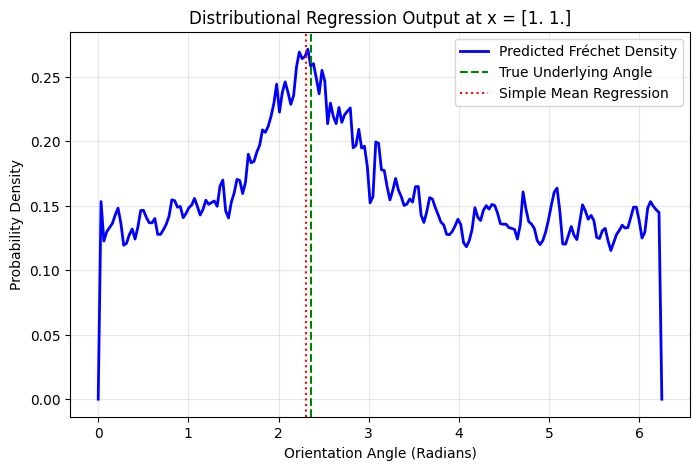

In [17]:

# Extract the mode of the Fréchet regressed density for comparison
frechet_mode_angle = theta[np.argmax(pred_density)]

print(f"Target Point: {x_test[0]}")
print(f"True Vector Angle:      {target_true_angle:.3f} rad")
print(f"Simple Mean Regression: {pred_mean_angle:.3f} rad")
print(f"Fréchet Density Mode:   {frechet_mode_angle:.3f} rad")

# Plot the resulting functional data
plt.figure(figsize=(8, 5))
plt.plot(theta, pred_density, label='Predicted Fréchet Density', color='blue', linewidth=2)
plt.axvline(target_true_angle, color='green', linestyle='--', label='True Underlying Angle')
plt.axvline(pred_mean_angle, color='red', linestyle=':', label='Simple Mean Regression')
plt.title(f"Distributional Regression Output at x = {x_test[0]}")
plt.xlabel("Orientation Angle (Radians)")
plt.ylabel("Probability Density")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()